In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df  = pd.read_csv('SuperMarket Analysis (1).csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [ ]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,Date,cogs,gross margin percentage,gross income,Rating,Hour
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1.000000e+03,1000.000000,1000.00000,1000.000000
mean,55.672130,5.510000,15.379369,322.966749,2019-02-14 00:05:45.600000,307.58738,4.761905e+00,15.379369,6.97270,14.910000
min,10.080000,1.000000,0.508500,10.678500,2019-01-01 00:00:00,10.17000,4.761905e+00,0.508500,4.00000,10.000000
25%,32.875000,3.000000,5.924875,124.422375,2019-01-24 00:00:00,118.49750,4.761905e+00,5.924875,5.50000,12.000000
50%,55.230000,5.000000,12.088000,253.848000,2019-02-13 00:00:00,241.76000,4.761905e+00,12.088000,7.00000,15.000000
75%,77.935000,8.000000,22.445250,471.350250,2019-03-08 00:00:00,448.90500,4.761905e+00,22.445250,8.50000,18.000000
max,99.960000,10.000000,49.650000,1042.650000,2019-03-30 00:00:00,993.00000,4.761905e+00,49.650000,10.00000,20.000000
std,26.494628,2.923431,11.708825,245.885335,NaN,234.17651,6.131498e-14,11.708825,1.71858,3.186857


In [ ]:
#Load and basic cleaning
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Hour'] = pd.to_datetime(df['Time']).dt.hour
df['DayOfWeek'] = df['Date'].dt.day_name()

In [ ]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hour,DayOfWeek
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,13,Saturday
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,10,Friday
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,13,Sunday
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,20,Sunday
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,10,Friday


In [ ]:
# Setting of visual style
sns.set_theme(style="whitegrid")

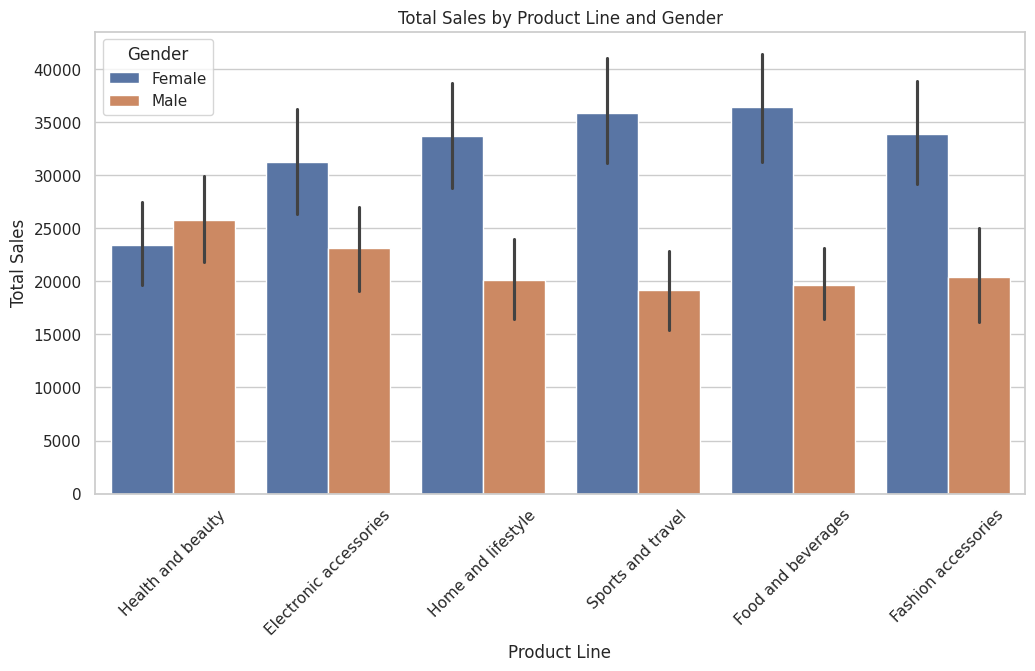

In [ ]:
#The plot of sales by product line and Gender
plt.figure(figsize=(12, 6))
sns.barplot(x='Product line', y='Sales', hue='Gender', estimator=sum, data=df)
plt.xticks(rotation=45)
plt.title('Total Sales by Product Line and Gender')
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.show()

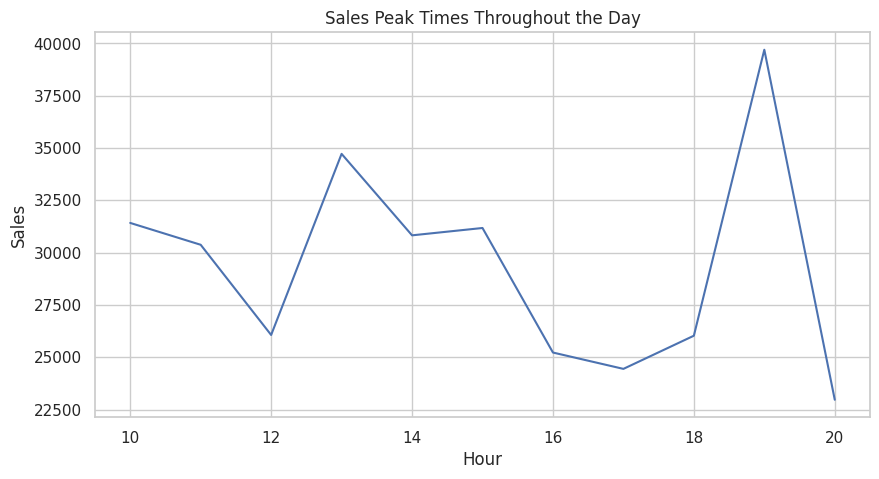

In [ ]:
# Plot of sales Trend by Hour of Day
plt.figure(figsize=(10, 5))
sns.lineplot(x='Hour', y='Sales', estimator=sum, ci=None, data=df)
plt.title('Sales Peak Times Throughout the Day')
plt.show()

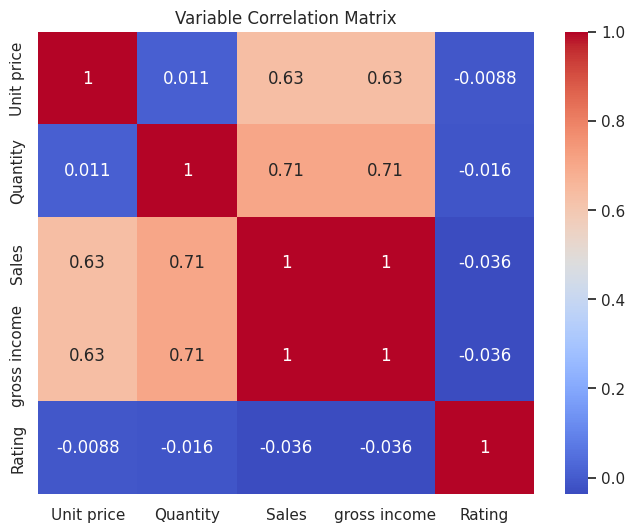

In [ ]:
# The correlation Heatmap (To see the relationship between unit price, quantity and rating)
plt.figure(figsize=(8, 6))
corr = df[['Unit price', 'Quantity', 'Sales', 'gross income', 'Rating']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Variable Correlation Matrix')
plt.show()

In [ ]:
# Calculate Average Unit Price and Total Quantity per Product Line
product_analysis = df.groupby('Product line').agg({
    'Unit price': 'mean',
    'Quantity': 'sum',
    'Sales': 'sum'
}).reset_index()

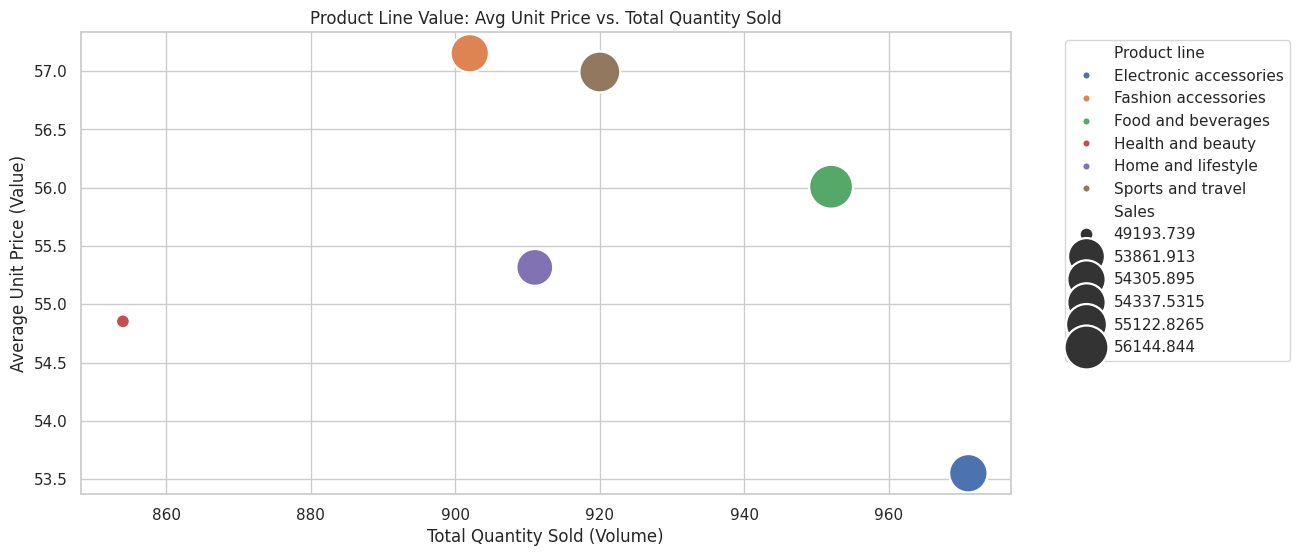

In [ ]:
# Plotting Unit Price vs Quantity
plt.figure(figsize=(12, 6))
sns.scatterplot(data=product_analysis, x='Quantity', y='Unit price',
                hue='Product line', size='Sales', sizes=(100, 1000))
plt.title('Product Line Value: Avg Unit Price vs. Total Quantity Sold')
plt.xlabel('Total Quantity Sold (Volume)')
plt.ylabel('Average Unit Price (Value)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
#Compare Average Spending per Transaction
avg_spend = df.groupby('Customer type')['Sales'].mean().reset_index()

In [ ]:
# Compare Total Revenue Contribution
total_spend = df.groupby('Customer type')['Sales'].sum().reset_index()

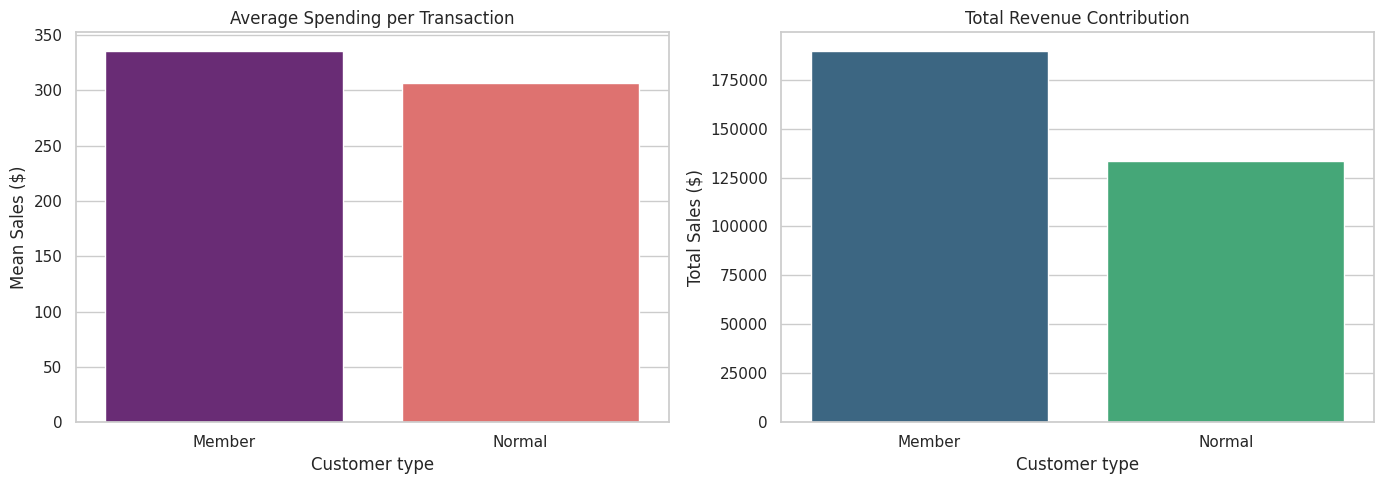

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=avg_spend, x='Customer type', y='Sales', ax=ax[0], palette='magma')
ax[0].set_title('Average Spending per Transaction')
ax[0].set_ylabel('Mean Sales ($)')

sns.barplot(data=total_spend, x='Customer type', y='Sales', ax=ax[1], palette='viridis')
ax[1].set_title('Total Revenue Contribution')
ax[1].set_ylabel('Total Sales ($)')

plt.tight_layout()
plt.show()

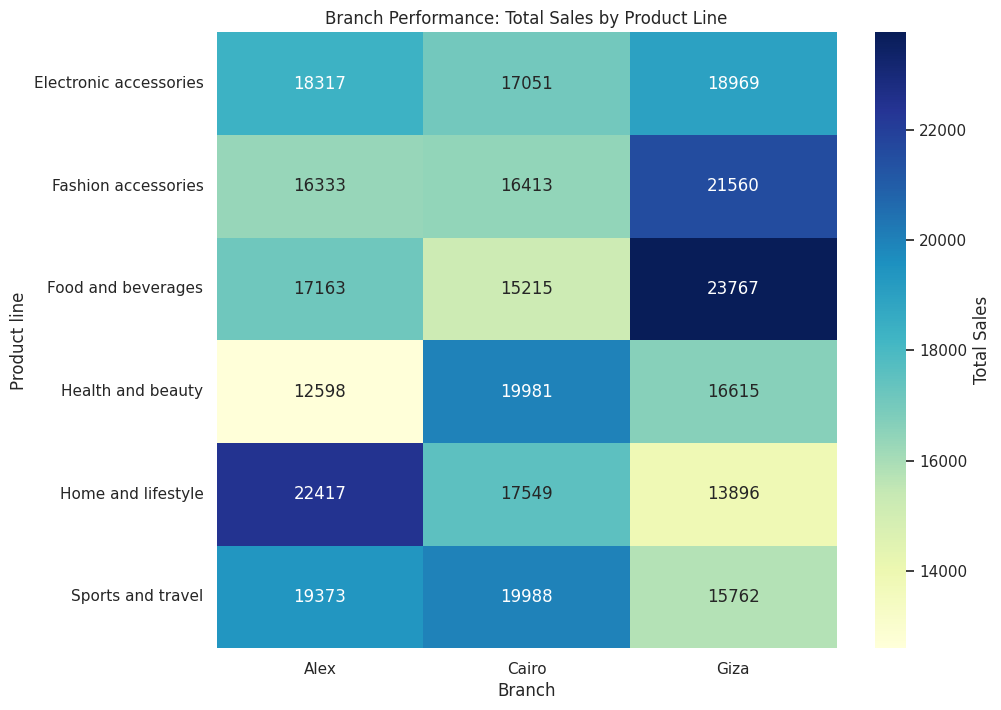

In [ ]:
# Create a pivot table for Branch and Product Line
branch_pivot = df.pivot_table(index='Product line',
                             columns='Branch',
                             values='Sales',
                             aggfunc='sum')

plt.figure(figsize=(10, 8))
sns.heatmap(branch_pivot, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Total Sales'})
plt.title('Branch Performance: Total Sales by Product Line')
plt.show()

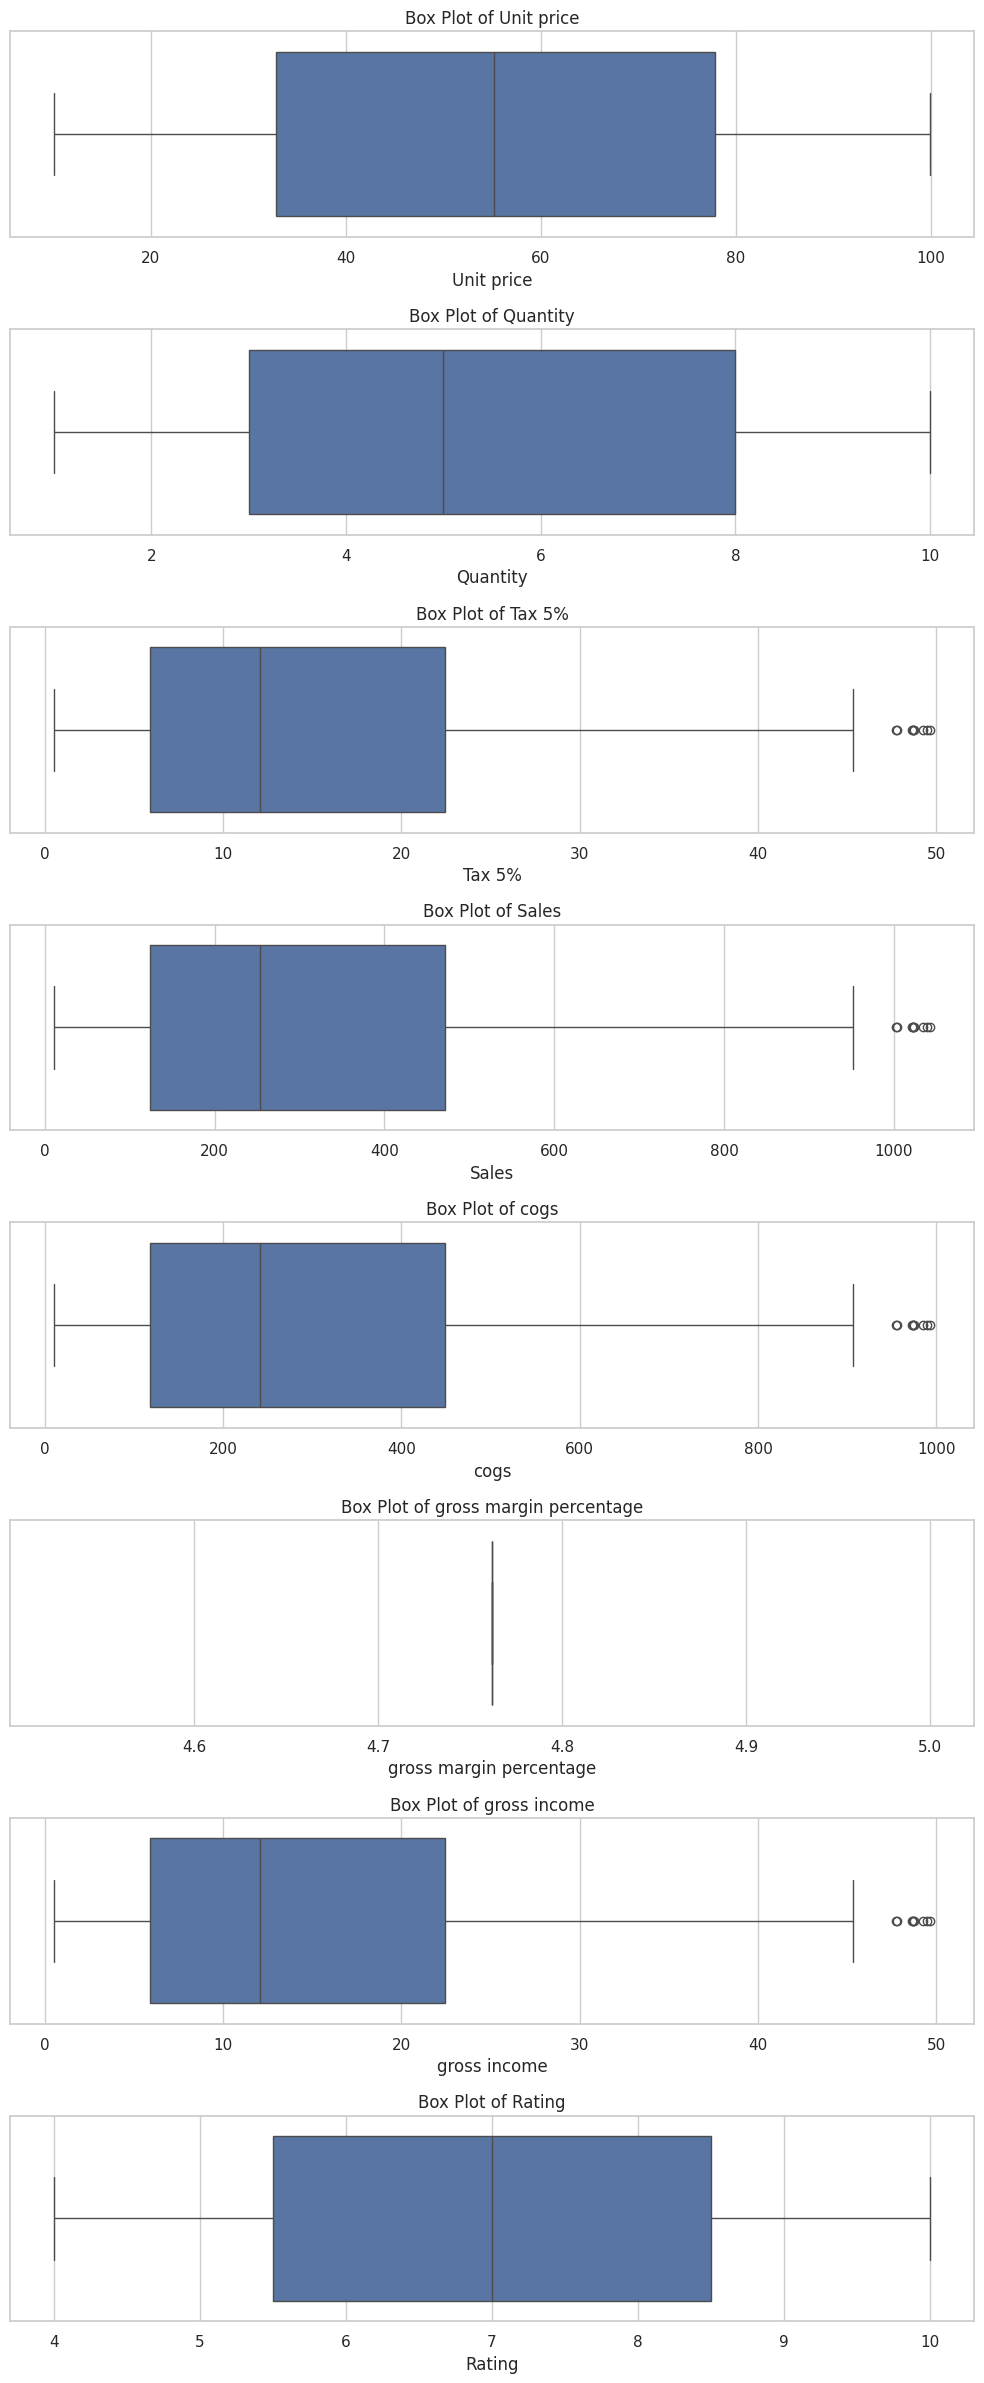

In [ ]:
# Checking of Outliers on the variables
# Filter numerical columns for box plots
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns

# Plot box plots for each numerical feature
plt.figure(figsize=(10, len(numerical_features) * 3))  # Adjust size based on the number of features
for i, col in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 1, i)
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.tight_layout()

plt.show()

In [ ]:
#Checking outliers
df.Sales.describe()

,Sales
count,1000.000000
mean,322.966749
std,245.885335
min,10.678500
25%,124.422375
50%,253.848000
75%,471.350250
max,1042.650000


In [ ]:
# To solve the sales ourl
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

Q1, Q3

(np.float64(124.422375), np.float64(471.35024999999996))

In [ ]:
IQR = Q3-Q1
IQR

np.float64(346.927875)

In [ ]:
lower_limit = Q1 - 1.5*IQR

upper_limit = Q3 + 1.5*IQR

lower_limit, upper_limit

(np.float64(-395.9694375), np.float64(991.7420625))

In [ ]:
# Build machine learning models to predict total sales.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Feature Engineering: Extracting time-based features
df['Date'] = pd.to_datetime(df['Date'])
df['Hour'] = pd.to_datetime(df['Time']).dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [ ]:
# I am remove 'Tax 5%', 'cogs', 'gross income', 'gross margin percentage', and 'Sales'
# because they are derived from the target 'Sales'.
features = ['Branch', 'City', 'Customer type', 'Gender', 'Product line',
            'Unit price', 'Quantity', 'Hour', 'DayOfWeek', 'Payment', 'Rating']
X = df[features]
y = df['Sales']

In [ ]:
# Identify column types
numeric_features = ['Unit price', 'Quantity', 'Hour', 'DayOfWeek', 'Rating']
categorical_features = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']

In [ ]:
# Preprocessing: Scale numbers and Encode text
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [ ]:
#Building the Machine Learning Models
# I will create a helper function to train and evaluate the models side-by-side.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(800, 11) (200, 11)
(800,) (200,)


In [ ]:
#Building Linear Regression model
import statsmodels.api as sm

# Preprocess the training data using the defined preprocessor
X_train_processed = preprocessor.fit_transform(X_train)

# Get the feature names after one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# Convert the processed data back to a DataFrame for statsmodels (optional but good for inspection)
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)

# Add a constant to get an intercept
X_train_sm = sm.add_constant(X_train_processed_df)

# Fit the regression line using OLS - Ordinary Least Squares
LR = sm.OLS(y_train, X_train_sm).fit()

In [ ]:
LR.params

,0
const,-1.007842e+15
Unit price,1.523523e+02
Quantity,1.716137e+02
Hour,-1.093193e+00
DayOfWeek,1.296699e-01
Rating,-5.076036e+00
Branch_Alex,-8.651583e+13
Branch_Cairo,-6.696846e+13
Branch_Giza,-7.908024e+13
City_Mandalay,-7.469227e+13


In [ ]:
print(LR.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     384.5
Date:                Thu, 22 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:38:16   Log-Likelihood:                -4657.9
No. Observations:                 800   AIC:                             9350.
Df Residuals:                     783   BIC:                             9430.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

In [ ]:
summary = LR.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     384.5
Date:                Thu, 22 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:38:49   Log-Likelihood:                -4657.9
No. Observations:                 800   AIC:                             9350.
Df Residuals:                     783   BIC:                             9430.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

In [ ]:
# Building Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Fit the pipeline to the training data
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Unit price', 'Quantity',
                                                   'Hour', 'DayOfWeek',
                                                   'Rating']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Branch', 'City',
                                                   'Customer type', 'Gender',
                                                   'Product line',
                                                   'Payment'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [ ]:
# The Random Forest predictions and evaluation

y_test_pred = rf_pipeline.predict(X_test)

results = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
print(results)

       Actual   Predicted
521  523.9710  531.226710
737  616.9800  578.636415
740  408.7335  408.359700
660  135.3555  139.365765
411   45.9270   49.366065
..        ...         ...
408  237.4260  234.028725
332  404.3550  392.502285
208   95.6655  100.992255
613   84.9765   84.336840
78   822.2550  810.728205

[200 rows x 2 columns]


In [ ]:
#To get the R-square, Mean Square Error and RMSE
r2 = r2_score(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)

print(f"\nR-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")


R-squared: 0.9983
Mean Squared Error: 108.2354
Root Mean Squared Error: 10.4036


In [ ]:
# Building XGBoost Pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5))
])

In [ ]:
# Helper function to train, predict, and evaluate models
def evaluate_model(pipeline, X_train, X_test, y_train, y_test, model_name):
    print(f"--- Evaluating {model_name} Model ---")

    # Fit the pipeline to the training data
    pipeline.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = pipeline.predict(X_test)

    # Calculate evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Print results
    print(f"R-squared: {r2:.4f}")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print("-" * 40)
    return y_pred

xgb_preds = evaluate_model(xgb_pipeline, X_train, X_test, y_train, y_test, "XGBoost")

--- Evaluating XGBoost Model ---
R-squared: 0.9991
Mean Squared Error: 56.3360
Root Mean Squared Error: 7.5057
----------------------------------------


Based on the results you provided, we can perform a comparative evaluation to select the best model.
1. Performance Comparison Table
Metric	OLS (Linear Regression)	Random Forest	XGBoost
R-squared	0.887	0.9983	0.9991
RMSE	Not provided (but high)	10.40	7.51
Key Issues	Multicollinearity (Note [2])	High Accuracy	Highest Accuracy

2. Model Evaluation
OLS Regression (The Baseline)
•	The Problem: Your OLS model is suffering from perfect multicollinearity. Look at the coefficients ($10^{15}$). This usually happens when "One-Hot Encoding" includes all categories (the "Dummy Variable Trap"), making the matrix singular.
•	Predictive Power: With an $R^2$ of 0.887, it is significantly weaker than the ensemble models. It is struggling to capture the non-linear relationship between quantity, unit price, and the target.
Random Forest
•	Performance: Excellent. An $R^2$ of 0.9983 and an RMSE of 10.40 means the model is, on average, only about 10.40 off from the actual transaction total.
•	Stability: Random Forest is robust to outliers and does not require the strict statistical assumptions that failed in your OLS model.
XGBoost (The Winner)
•	Performance: This is your best-performing model. It has the highest $R^2$ (0.9991) and the lowest RMSE (7.51).
•	Efficiency: XGBoost is predicting sales with nearly 99.9% accuracy, and its error is roughly 28% lower than the Random Forest ($7.51$ vs $10.40$).

3. Final Model Selection: XGBoost
Reason for  XGBoost?
Superior Error Metrics: It provides the most precise "Total Sales" forecast.
Handling Features: Unlike OLS, XGBoost handled your categorical variables (City, Branch, etc.) without the coefficients exploding.
Refinement: It uses gradient boosting to correct the errors made by previous trees, which explains why it surpassed the Random Forest.
4. Diagnostic: Why is accuracy so high?
An $R^2$ of 0.999 is nearly "perfect." In a supermarket context, this usually suggests that the model has identified the exact mathematical formula used to calculate Sales.
